In [62]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import joblib
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

## LINEAR REGRESSION

In [4]:
df  = pd.read_csv(r"D:\Smart Factory\smart factory machinery data set.csv")
df.head(5)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Mean Squared Error: 2.2004291212555707
Intercept: 309.7600762316204
Coefficient: 0.00015953183077091124


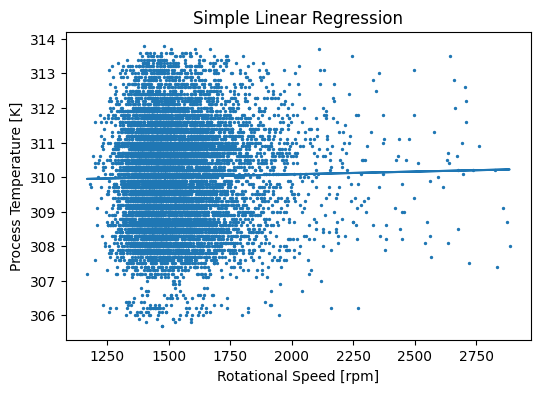

In [51]:
x = df[["Rotational speed [rpm]"]]
y = df["Process temperature [K]"]
model = LinearRegression()
model.fit(x, y)
y_pred = model.predict(x)
y_pred[:5]
mse = mean_squared_error(y, y_pred)
print("Mean Squared Error:", mse)
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])
plt.figure(figsize = (6, 4))
plt.scatter(x,y,s =2)
plt.plot(x,y_pred)
plt.xlabel("Rotational Speed [rpm]")
plt.ylabel("Process Temperature [K]")
plt.title("Simple Linear Regression")
plt.show()

## MULTI-LINEAR REGRESSION

In [29]:
df = pd.read_csv("smart factory machinery data set.csv")
df.head()
X = df[[
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]]
y = df["Process temperature [K]"]
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
y_pred[:5]
mse = mean_squared_error(y, y_pred)
print("Multivariable Regression MSE:", mse)
print("Intercept:", model.intercept_)
print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(feature, ":", coef)
print("Task 1 used only one feature (RPM).")
print("Task 2 uses multiple features.")
print("Adding relevant features usually reduces error and improves prediction.")

Multivariable Regression MSE: 2.1999528448038213
Intercept: 309.5184618305241
Coefficients:
Rotational speed [rpm] : 0.0002474655065226065
Torque [Nm] : 0.0018077985553836455
Tool wear [min] : 0.00031510485620540987
Task 1 used only one feature (RPM).
Task 2 uses multiple features.
Adding relevant features usually reduces error and improves prediction.


## SAVE AND LOAD MODEL

In [33]:
target_col = "Process temperature [K]"
feature_cols = [
    "Type",
    "Air temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

X = df[feature_cols].copy()
y = df[target_col]

cat_cols = ["Type"]
num_cols = [col for col in feature_cols if col not in cat_cols]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

joblib.dump(model, "temperature_prediction_model.pkl")

print("Model saved successfully")
print("Test MSE:", mse)
print("Predicted temperature for first test row:", y_pred[0])


Model saved successfully
Test MSE: 0.5305603733573
Predicted temperature for first test row: 310.5301356545908


In [36]:
model = joblib.load("temperature_prediction_model.pkl")

new_data = pd.DataFrame({
    "Type": ["L"],
    "Air temperature [K]": [298.5],
    "Rotational speed [rpm]": [1500],
    "Torque [Nm]": [40.0],
    "Tool wear [min]": [120]
})

prediction = model.predict(new_data)

print("Predicted Temperature:", prediction[0])

Predicted Temperature: 309.0304108244951


## ONE-HOT ENCODING

In [39]:
df["Machine Mode"] = ["Eco", "Standard", "High-Speed"] * (len(df) // 3) + ["Eco"] * (len(df) % 3)
encoded_df = pd.get_dummies(df, columns=["Machine Mode"], drop_first=True)
print(encoded_df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  Machine Mode_High-Speed  Machine Mode_Standard  
0    0  

## TRAIN TEST SPLIT

Test MSE: 0.5262766757748052


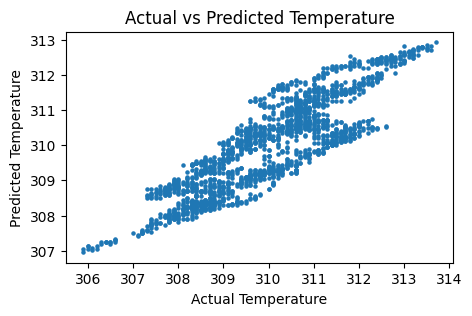

In [64]:
df = pd.read_csv("smart factory machinery data set.csv")

df = pd.get_dummies(df, columns=["Type"], drop_first=True)

X = df.drop(["UDI", "Product ID", "Process temperature [K]"], axis=1)
y = df["Process temperature [K]"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

prediction = model.predict(X_test)

mse = mean_squared_error(y_test, prediction)

print("Test MSE:", mse)

plt.figure(figsize = (5, 3))
plt.scatter(y_test, prediction, s = 5)

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")

plt.title("Actual vs Predicted Temperature")

plt.show()

## LOGISTIC REGRESSION

Accuracy: 0.974
Confusion Matrix: [[1930    9]
 [  43   18]]


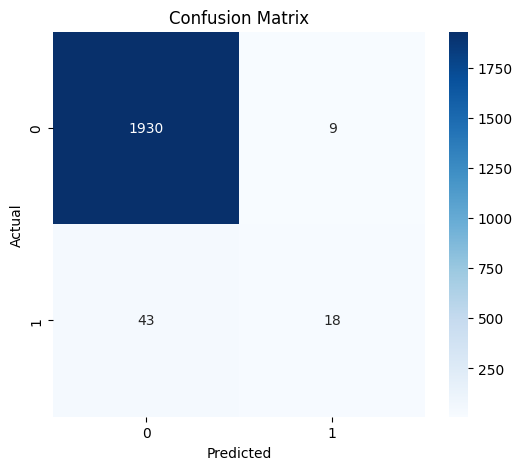

Predicted Machine Failure: [0]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1939
           1       0.67      0.30      0.41        61

    accuracy                           0.97      2000
   macro avg       0.82      0.65      0.70      2000
weighted avg       0.97      0.97      0.97      2000



In [63]:
encoded_df = df.drop(columns=["UDI", "Product ID"])
encoded_df = pd.get_dummies(encoded_df, columns=["Type"], drop_first=True, dtype=int)

X = encoded_df.drop('Machine failure', axis=1)
y = encoded_df['Machine failure']
X = encoded_df.drop([
    'Machine failure',
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'RNF'
], axis=1)
y = encoded_df['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_log)
print("Accuracy:", accuracy)
cm = confusion_matrix(y_test, y_pred_log)
print("Confusion Matrix:", cm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

new_machine = pd.DataFrame({
    'Air temperature [K]': [298.5],
    'Process temperature [K]': [310],
    'Rotational speed [rpm]': [1500],
    'Torque [Nm]': [40],
    'Tool wear [min]': [10],
    'Type_L': [0],
    'Type_M': [1]
})
prediction = log_model.predict(new_machine)
print("Predicted Machine Failure:", prediction)

print(classification_report(y_test, y_pred_log))
